# ARTI403 - Image Processing
## Lab 2: Digital Image Fundamentals



### Step 0: Install packages and download the sample images (run once)

In [1]:
%pip install -q opencv-python numpy pillow matplotlib

import os

images_dir = os.path.join(os.getcwd(), 'images')
os.makedirs(images_dir, exist_ok=True)

base_url = 'https://raw.githubusercontent.com/mohammadimtiazz/standard-test-images-for-Image-Processing/master/standard_test_images'
files = ['cameraman.tif', 'lena_gray_256.tif']

for f in files:
    dest = os.path.join(images_dir, f)
    url = f'{base_url}/{f}'
    !curl -L -s -o "{dest}" "{url}"
    size = os.path.getsize(dest) if os.path.exists(dest) else 0
    print(f'{f}: {"OK" if size > 0 else "FAILED"} ({size} bytes) -> {dest}')

Note: you may need to restart the kernel to use updated packages.
cameraman.tif: OK (262750 bytes) -> c:\Users\dania\Image_Processing_Labs\Lab2\images\cameraman.tif
lena_gray_256.tif: OK (65798 bytes) -> c:\Users\dania\Image_Processing_Labs\Lab2\images\lena_gray_256.tif


### Step 0b: Generate A.png and B.png for the set/logical operations section

In [2]:
import numpy as np
from PIL import Image, ImageDraw

size = (300, 300)

# A.png: a white square on a black background
imgA = Image.new('L', size, 0)
drawA = ImageDraw.Draw(imgA)
drawA.rectangle([50, 50, 220, 220], fill=255)
imgA.save(os.path.join(images_dir, 'A.png'))

# B.png: a white circle, overlapping the square
imgB = Image.new('L', size, 0)
drawB = ImageDraw.Draw(imgB)
drawB.ellipse([120, 120, 280, 280], fill=255)
imgB.save(os.path.join(images_dir, 'B.png'))

print('Generated A.png and B.png in', images_dir)

Generated A.png and B.png in c:\Users\dania\Image_Processing_Labs\Lab2\images


## 1. Image Sampling and Quantization

### Step#1: Import the libraries

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Step#2: Define functions

In [4]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.
    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.
    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.
    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.
    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.
    Args:
        original (numpy array): Original image.
        sampled (numpy array): Sampled image.
        quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')
    plt.show()

### Step#3: Import the image and set the parameters

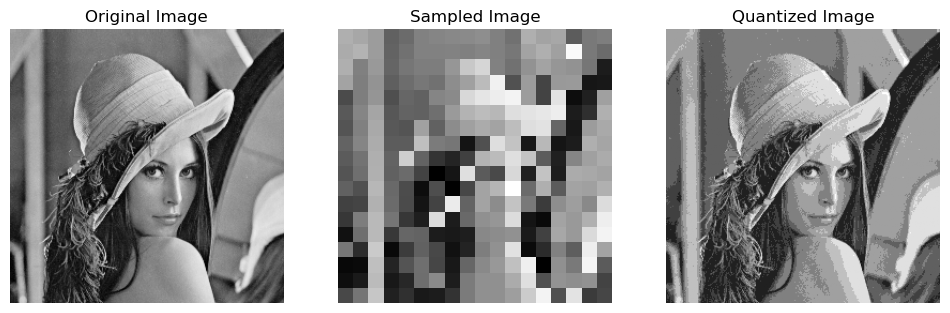

In [5]:
image_path = os.path.join('images', 'lena_gray_256.tif')
sampling_factor = 14
quantization_levels = 9

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f'Error: Unable to load image at {image_path}')

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)

### Task#1: Change the sampling and quantization parameters and observe the effects
Try a few different values below and re-run the cell to compare the results.

sampling_factor=2, quantization_levels=2


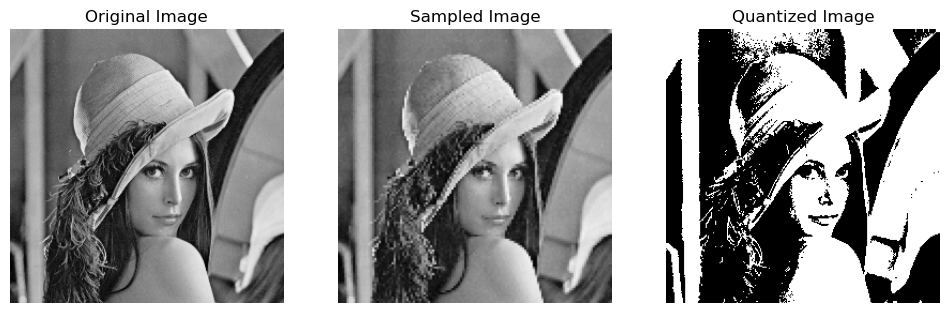

sampling_factor=8, quantization_levels=4


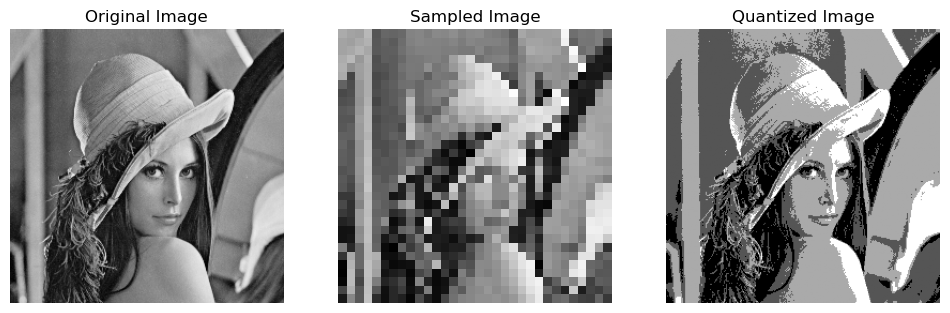

sampling_factor=20, quantization_levels=16


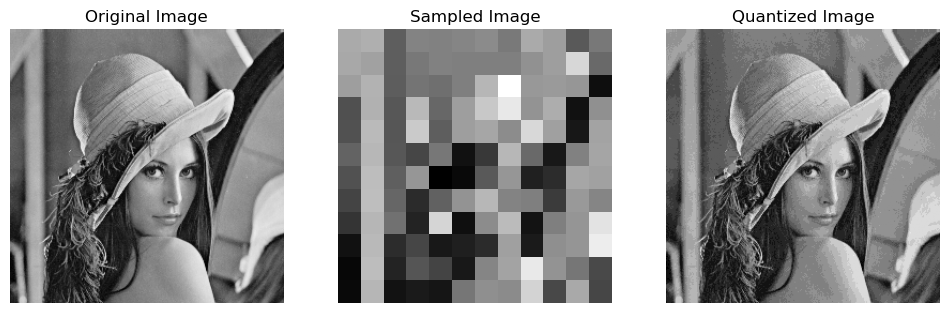

In [6]:
for factor, levels in [(2, 2), (8, 4), (20, 16)]:
    print(f'sampling_factor={factor}, quantization_levels={levels}')
    sampled_image = sample_image(original_image, factor)
    quantized_image = quantize_image(original_image, levels)
    plot_images(original_image, sampled_image, quantized_image)

## 2. Arithmetic Operations

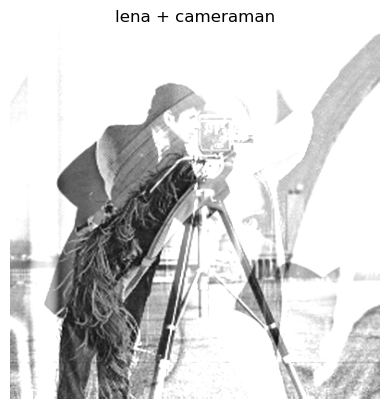

In [7]:
from PIL import Image

img1 = Image.open(os.path.join('images', 'lena_gray_256.tif'))
img2 = Image.open(os.path.join('images', 'cameraman.tif'))

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1).astype(np.uint16)  # widen dtype so the addition below doesn't wrap around
im2arr = np.asarray(img2).astype(np.uint16)

addition = np.clip(im1arr + im2arr, 0, 255).astype(np.uint8)
resultImage = Image.fromarray(addition)

plt.imshow(resultImage, cmap='gray')
plt.title('lena + cameraman')
plt.axis('off')
plt.show()

## 3. Sets and Logical Operations

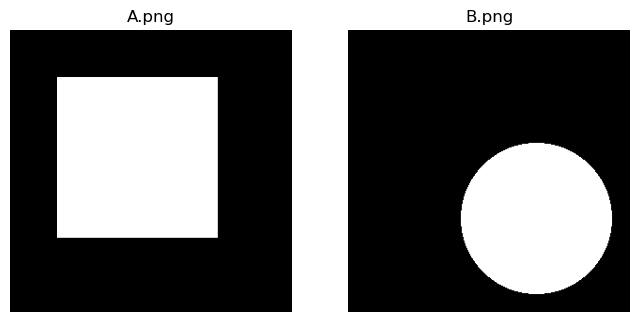

In [8]:
img3 = Image.open(os.path.join('images', 'A.png'))
img4 = Image.open(os.path.join('images', 'B.png'))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img3, cmap='gray'); axes[0].set_title('A.png'); axes[0].axis('off')
axes[1].imshow(img4, cmap='gray'); axes[1].set_title('B.png'); axes[1].axis('off')
plt.show()

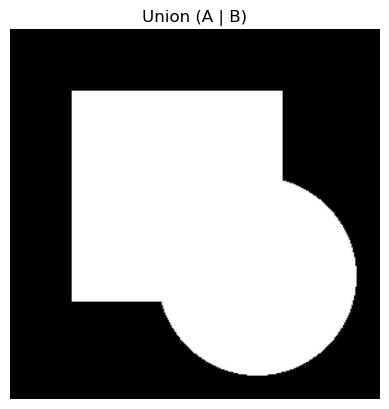

In [9]:
resize = (400, 400)
img3 = img3.resize(resize, Image.Resampling.LANCZOS)
img4 = img4.resize(resize, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
resultImage2 = Image.fromarray(union)

plt.imshow(resultImage2, cmap='gray')
plt.title('Union (A | B)')
plt.axis('off')
plt.show()

## 4. Assessment: Task#2
Read two images, convert them into arrays, and perform the following operations on them:
1. Subtract two images and display the result.
2. Add one image with a constant value of 175 and display it.
3. Apply the set difference operation on two grayscale images.
4. Apply the symmetric difference operation on two grayscale images.
5. Apply the intersection operation on two grayscale images.

### 1. Subtraction

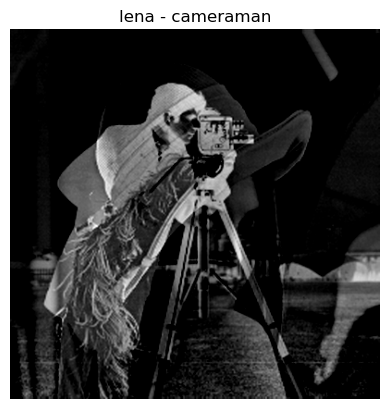

In [10]:
subtraction = np.clip(im1arr.astype(np.int16) - im2arr.astype(np.int16), 0, 255).astype(np.uint8)

plt.imshow(subtraction, cmap='gray')
plt.title('lena - cameraman')
plt.axis('off')
plt.show()

### 2. Add a constant value of 175

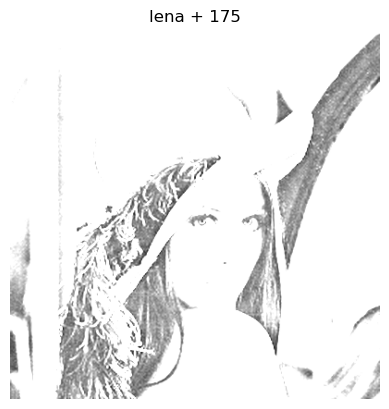

In [11]:
added_constant = np.clip(im1arr.astype(np.int16) + 175, 0, 255).astype(np.uint8)

plt.imshow(added_constant, cmap='gray')
plt.title('lena + 175')
plt.axis('off')
plt.show()

### 3. Set difference (A AND NOT B)

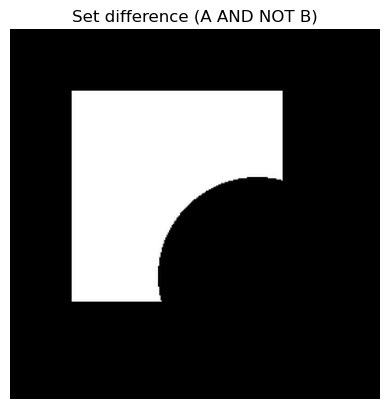

In [12]:
set_difference = im3arr & (~im4arr)

plt.imshow(set_difference, cmap='gray')
plt.title('Set difference (A AND NOT B)')
plt.axis('off')
plt.show()

### 4. Symmetric difference (A XOR B)

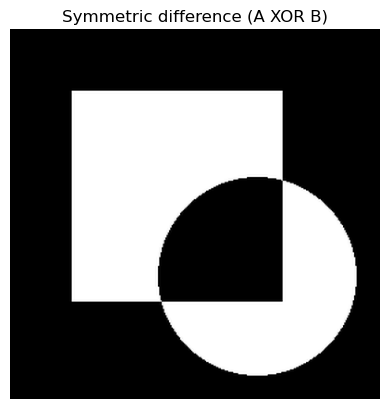

In [13]:
symmetric_difference = im3arr ^ im4arr

plt.imshow(symmetric_difference, cmap='gray')
plt.title('Symmetric difference (A XOR B)')
plt.axis('off')
plt.show()

### 5. Intersection (A AND B)

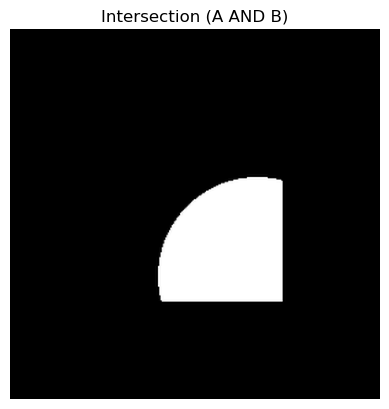

In [14]:
intersection = im3arr & im4arr

plt.imshow(intersection, cmap='gray')
plt.title('Intersection (A AND B)')
plt.axis('off')
plt.show()